In [2]:
!pip install torch torchvision pillow matplotlib

In [3]:
import torch
print("Torch working ✅")

Torch working ✅


Processing...
Done ✅


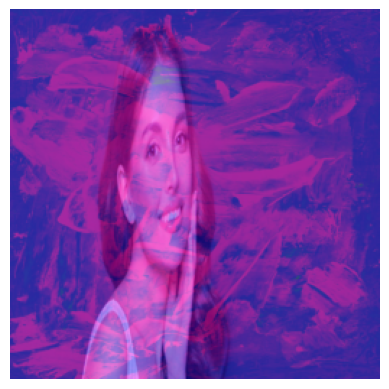

In [5]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# -------------------- Image Loading Function --------------------

# Function to load and preprocess an image
def load_image(path):
    # Open image and convert to RGB format
    image = Image.open(path).convert('RGB')
    
    # Define transformations: resize and convert to tensor
    transform = transforms.Compose([
        transforms.Resize((256,256)),  # Resize image to 256x256
        transforms.ToTensor()          # Convert image to PyTorch tensor
    ])
    
    # Apply transformations and add batch dimension
    image = transform(image).unsqueeze(0)
    
    return image

# Load content and style images from files
content = load_image("content.jpg")
style = load_image("style.jpg")

# -------------------- Initialization --------------------

# Create output image (start from content image)
# requires_grad=True allows optimization on this tensor
output = content.clone().requires_grad_(True)

# Adam optimizer to update the output image
optimizer = torch.optim.Adam([output], lr=0.01)

print("Processing...")

# -------------------- Optimization Loop --------------------

# Run optimization for 50 iterations
for i in range(50):
    
    # Clear previous gradients
    optimizer.zero_grad()
    
    # Compute loss:
    # 1. Content loss (difference from content image)
    # 2. Style loss (difference from style image)
    loss = torch.mean((output - content)**2) + torch.mean((output - style)**2)
    
    # Backpropagation (compute gradients)
    loss.backward()
    
    # Update output image
    optimizer.step()

print("Done ✅")

# -------------------- Display Result --------------------

# Detach from computation graph and remove batch dimension
result = output.detach().squeeze()

# Convert tensor format (C,H,W) → (H,W,C) for displaying
plt.imshow(result.permute(1,2,0))

# Remove axis for cleaner display
plt.axis('off')

# Show the final stylized image
plt.show()

# -------------------- Save Output --------------------

# Save the result image to file
plt.imsave("output.jpg", result.permute(1,2,0))